# 🔌 Attention-Based Multi-Resolution Deep Learning Framework
## Multi-Horizon Electricity Load Forecasting — Tamil Nadu & Kerala

> **Run cells top-to-bottom.** Upload your Excel file when prompted in Cell 2.

| Cell | What it does |
|------|--------------|
| 1 | Install packages |
| 2 | Upload dataset + parse |
| 3 | Feature engineering |
| 4 | EDA plots (real data) |
| 5 | Sequence builder + train/val/test split |
| 6 | Sklearn baselines |
| 7 | Deep learning: LSTM / GRU / CNN-LSTM |
| 8 | **Proposed: Multi-Resolution Attention LSTM** |
| 9 | Results tables |
|10 | Paper-quality plots |
|11 | Download all outputs |

In [ ]:
# ─── CELL 1: Install Required Packages ───────────────────────────
!pip install openpyxl -q          # Excel reader
# TensorFlow is pre-installed in Colab; verify:
import tensorflow as tf
import sklearn, pandas, numpy, matplotlib
print(f"✔ TensorFlow  {tf.__version__}")
print(f"✔ scikit-learn {sklearn.__version__}")
print("✔ All packages ready")

✔ TensorFlow  2.19.0
✔ scikit-learn 1.6.1
✔ All packages ready


In [ ]:
# ─── CELL 2: Upload Dataset ───────────────────────────────────────
from google.colab import files
import pandas as pd, numpy as np, os

print("📂 Please upload:  TN_Kerala_Hourly_Demand_2023-2025_.xlsx")
uploaded = files.upload()

FILENAME = list(uploaded.keys())[0]
print(f"\n✔ Uploaded: {FILENAME}")

# ── Parse Date_Hour + Year → proper datetime ──────────────────────
df_raw = pd.read_excel(FILENAME)
print(f"Raw shape : {df_raw.shape}")
print(df_raw.head(3))

def parse_dh(row):
    dp, tp = row["Date_Hour"].rsplit(" ", 1)
    return pd.to_datetime(f"{dp}-{row['Year']} {tp}", format="%d-%b-%Y %I%p")

df_raw["Datetime"] = df_raw.apply(parse_dh, axis=1)
df_raw.sort_values(["Datetime","State"], inplace=True)
df_raw.reset_index(drop=True, inplace=True)

print(f"\n✔ Date range : {df_raw['Datetime'].min()}  →  {df_raw['Datetime'].max()}")
print(f"✔ Missing    : {df_raw['Demand_MW'].isna().sum()}")
print(f"✔ States     : {df_raw['State'].unique().tolist()}")
print("\n── Demand Statistics ───────────────────────────────────────")
print(df_raw.groupby("State")["Demand_MW"].describe().round(2))

📂 Please upload:  TN_Kerala_Hourly_Demand_2023-2025_.xlsx


Saving TN Kerala Hourly Demand(2023-2025).xlsx to TN Kerala Hourly Demand(2023-2025) (1).xlsx

✔ Uploaded: TN Kerala Hourly Demand(2023-2025) (1).xlsx
Raw shape : (43776, 4)
   Year       State    Date_Hour  Demand_MW
0  2023  Tamil Nadu  01-Jan 12am   10835.43
1  2023  Tamil Nadu   01-Jan 1am   10745.17
2  2023  Tamil Nadu   01-Jan 2am   10575.02

✔ Date range : 2023-01-01 00:00:00  →  2025-06-30 23:00:00
✔ Missing    : 0
✔ States     : ['Kerala', 'Tamil Nadu']

── Demand Statistics ───────────────────────────────────────
              count      mean      std      min       25%       50%       75%  \
State                                                                           
Kerala      21888.0   3482.71   522.42  1672.57   3107.46   3414.98   3813.00   
Tamil Nadu  21888.0  14766.55  2021.59  7178.68  13495.37  14902.29  16203.03   

                max  
State                
Kerala       5762.0  
Tamil Nadu  20393.0  


In [ ]:
# ─── CELL 3: Feature Engineering ─────────────────────────────────

def add_temporal_features(data):
    d = data.copy()
    d["HourOfDay"]  = d["Datetime"].dt.hour
    d["DayOfWeek"]  = d["Datetime"].dt.dayofweek
    d["DayOfMonth"] = d["Datetime"].dt.day
    d["Month"]      = d["Datetime"].dt.month
    d["Quarter"]    = d["Datetime"].dt.quarter
    d["IsWeekend"]  = (d["DayOfWeek"] >= 5).astype(int)
    d["WeekOfYear"] = d["Datetime"].dt.isocalendar().week.astype(int)

    # Cyclical encoding (no discontinuity at boundary)
    d["Hour_sin"]  = np.sin(2 * np.pi * d["HourOfDay"] / 24)
    d["Hour_cos"]  = np.cos(2 * np.pi * d["HourOfDay"] / 24)
    d["DoW_sin"]   = np.sin(2 * np.pi * d["DayOfWeek"] / 7)
    d["DoW_cos"]   = np.cos(2 * np.pi * d["DayOfWeek"] / 7)
    d["Mon_sin"]   = np.sin(2 * np.pi * (d["Month"] - 1) / 12)
    d["Mon_cos"]   = np.cos(2 * np.pi * (d["Month"] - 1) / 12)
    return d

def add_lag_features(data):
    d = data.copy()
    for state, grp in d.groupby("State"):
        idx = grp.index
        for lag in [1, 6, 12, 24, 48, 168]:
            d.loc[idx, f"Lag_{lag}h"]  = grp["Demand_MW"].shift(lag)
        d.loc[idx, "Roll24_mean"]  = grp["Demand_MW"].shift(1).rolling(24).mean()
        d.loc[idx, "Roll24_std"]   = grp["Demand_MW"].shift(1).rolling(24).std()
        d.loc[idx, "Roll168_mean"] = grp["Demand_MW"].shift(1).rolling(168).mean()
    return d

df = add_temporal_features(df_raw)
df = add_lag_features(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✔ Shape after feature engineering : {df.shape}")
print(f"✔ Features created : {[c for c in df.columns if c not in df_raw.columns]}")

✔ Shape after feature engineering : (43440, 27)
✔ Features created : ['HourOfDay', 'DayOfWeek', 'DayOfMonth', 'Month', 'Quarter', 'IsWeekend', 'WeekOfYear', 'Hour_sin', 'Hour_cos', 'DoW_sin', 'DoW_cos', 'Mon_sin', 'Mon_cos', 'Lag_1h', 'Lag_6h', 'Lag_12h', 'Lag_24h', 'Lag_48h', 'Lag_168h', 'Roll24_mean', 'Roll24_std', 'Roll168_mean']


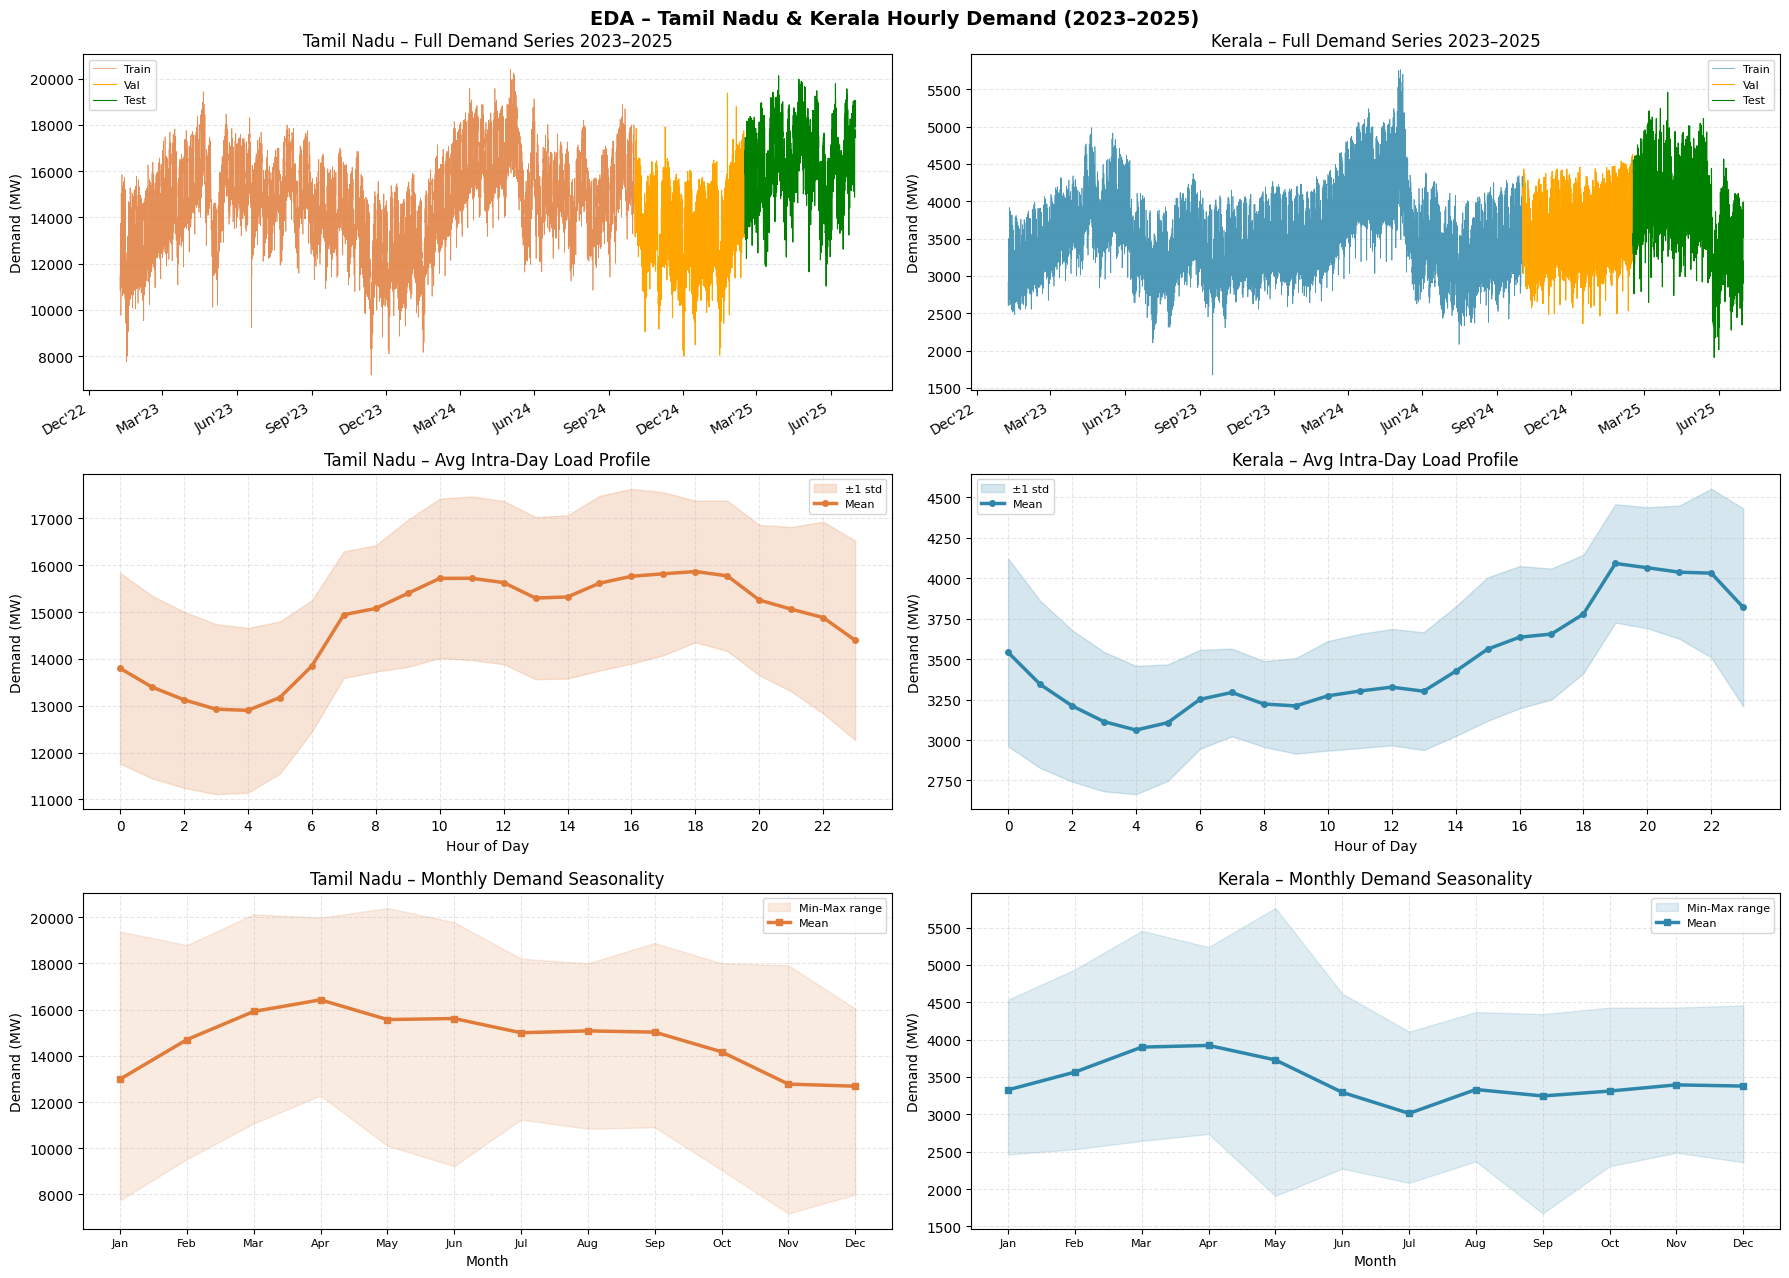

✅ EDA plot saved


In [ ]:
# ─── CELL 4: Exploratory Data Analysis (Real Data) ───────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

COLORS = {"Tamil Nadu": "#E07B39", "Kerala": "#2E86AB"}
os.makedirs("/content/outputs/plots", exist_ok=True)

fig, axes = plt.subplots(3, 2, figsize=(18, 13))
fig.suptitle("EDA – Tamil Nadu & Kerala Hourly Demand (2023–2025)",
             fontsize=14, fontweight="bold")

# Row 1: Full time series with splits
for i, state in enumerate(["Tamil Nadu", "Kerala"]):
    ax = axes[0, i]
    sub = df[df["State"] == state].sort_values("Datetime")
    n   = len(sub)
    n_tr, n_val = int(0.70*n), int(0.15*n)
    ax.plot(sub["Datetime"].values[:n_tr],
            sub["Demand_MW"].values[:n_tr],
            color=COLORS[state], lw=0.5, label="Train", alpha=0.85)
    ax.plot(sub["Datetime"].values[n_tr:n_tr+n_val],
            sub["Demand_MW"].values[n_tr:n_tr+n_val],
            color="orange", lw=0.8, label="Val")
    ax.plot(sub["Datetime"].values[n_tr+n_val:],
            sub["Demand_MW"].values[n_tr+n_val:],
            color="green", lw=0.8, label="Test")
    ax.set_title(f"{state} – Full Demand Series 2023–2025")
    ax.set_ylabel("Demand (MW)")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b'%y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

# Row 2: Average intra-day profile with std band
for i, state in enumerate(["Tamil Nadu", "Kerala"]):
    ax = axes[1, i]
    sub = df[df["State"] == state]
    hp  = sub.groupby("HourOfDay")["Demand_MW"].agg(["mean","std"])
    ax.fill_between(hp.index, hp["mean"]-hp["std"], hp["mean"]+hp["std"],
                    alpha=0.2, color=COLORS[state], label="±1 std")
    ax.plot(hp.index, hp["mean"], color=COLORS[state],
            lw=2.5, marker="o", ms=4, label="Mean")
    ax.set_title(f"{state} – Avg Intra-Day Load Profile")
    ax.set_xlabel("Hour of Day"); ax.set_ylabel("Demand (MW)")
    ax.set_xticks(range(0,24,2)); ax.legend(fontsize=8)
    ax.grid(linestyle="--", alpha=0.3)

# Row 3: Monthly seasonality
month_labels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
for i, state in enumerate(["Tamil Nadu", "Kerala"]):
    ax = axes[2, i]
    sub = df[df["State"] == state]
    mp  = sub.groupby("Month")["Demand_MW"].agg(["mean","min","max"])
    ax.fill_between(mp.index, mp["min"], mp["max"],
                    alpha=0.15, color=COLORS[state], label="Min-Max range")
    ax.plot(mp.index, mp["mean"], color=COLORS[state],
            lw=2.5, marker="s", ms=5, label="Mean")
    ax.set_title(f"{state} – Monthly Demand Seasonality")
    ax.set_xlabel("Month"); ax.set_ylabel("Demand (MW)")
    ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels, fontsize=8)
    ax.legend(fontsize=8); ax.grid(linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("/content/outputs/plots/01_EDA.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA plot saved")

In [ ]:
# ─── CELL 5: Sequence Builder + Train/Val/Test Split ─────────────
from sklearn.preprocessing import MinMaxScaler
import pickle

SEQ_LEN  = 48        # 48-hour look-back window
HORIZONS = [1, 6, 24]  # forecast horizons (hours ahead)

FEATURE_COLS = [
    "Hour_sin","Hour_cos","DoW_sin","DoW_cos","Mon_sin","Mon_cos",
    "IsWeekend","Quarter",
    "Lag_1h","Lag_6h","Lag_12h","Lag_24h","Lag_48h","Lag_168h",
    "Roll24_mean","Roll24_std","Roll168_mean"
]
TARGET = "Demand_MW"

def make_sequences(X, y, seq_len, horizon):
    Xs, ys = [], []
    for i in range(len(X) - seq_len - horizon + 1):
        Xs.append(X[i : i+seq_len])
        ys.append(y[i + seq_len + horizon - 1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

def calc_metrics(actual, pred):
    mae  = float(np.mean(np.abs(actual - pred)))
    rmse = float(np.sqrt(np.mean((actual - pred)**2)))
    mask = actual != 0
    mape = float(np.mean(np.abs((actual[mask]-pred[mask])/actual[mask]))*100)
    return {"MAE": round(mae,2), "RMSE": round(rmse,2), "MAPE": round(mape,4)}

# ── Split + scale per state ────────────────────────────────────────
scalers, splits, seqs_all = {}, {}, {}

for state in ["Tamil Nadu", "Kerala"]:
    sub = df[df["State"]==state].sort_values("Datetime").reset_index(drop=True)
    n   = len(sub)
    n_tr, n_val = int(0.70*n), int(0.15*n)
    train, val, test = sub.iloc[:n_tr], sub.iloc[n_tr:n_tr+n_val], sub.iloc[n_tr+n_val:]

    sX = MinMaxScaler(); sy = MinMaxScaler()
    X_tr = sX.fit_transform(train[FEATURE_COLS])
    y_tr = sy.fit_transform(train[[TARGET]]).ravel()
    X_va = sX.transform(val[FEATURE_COLS]);   y_va = sy.transform(val[[TARGET]]).ravel()
    X_te = sX.transform(test[FEATURE_COLS]);  y_te = sy.transform(test[[TARGET]]).ravel()

    scalers[state] = (sX, sy)
    splits[state]  = (X_tr, y_tr, X_va, y_va, X_te, y_te,
                      test["Datetime"].values, test[TARGET].values)

    seqs = {}
    for h in HORIZONS:
        seqs[h] = (*make_sequences(X_tr,y_tr,SEQ_LEN,h),
                   *make_sequences(X_va,y_va,SEQ_LEN,h),
                   *make_sequences(X_te,y_te,SEQ_LEN,h))
    seqs_all[state] = seqs

    print(f"  {state}")
    print(f"    Train {train['Datetime'].iloc[0].date()} → {train['Datetime'].iloc[-1].date()}  ({n_tr:,})")
    print(f"    Val   {val['Datetime'].iloc[0].date()} → {val['Datetime'].iloc[-1].date()}   ({n_val:,})")
    print(f"    Test  {test['Datetime'].iloc[0].date()} → {test['Datetime'].iloc[-1].date()}   ({len(test):,})")
    print(f"    Seq shape (1h): {seqs[1][0].shape}\n")

N_FEATURES = len(FEATURE_COLS)
print(f"✔ n_features = {N_FEATURES}")
ALL_RESULTS = {s: {} for s in ["Tamil Nadu","Kerala"]}

  Tamil Nadu
    Train 2023-01-08 → 2024-10-02  (15,203)
    Val   2024-10-02 → 2025-02-15   (3,258)
    Test  2025-02-15 → 2025-06-30   (3,259)
    Seq shape (1h): (15155, 48, 17)

  Kerala
    Train 2023-01-08 → 2024-10-02  (15,203)
    Val   2024-10-02 → 2025-02-15   (3,258)
    Test  2025-02-15 → 2025-06-30   (3,259)
    Seq shape (1h): (15155, 48, 17)

✔ n_features = 17


In [ ]:
# ─── CELL 6: Sklearn Baseline Models ─────────────────────────────
from sklearn.linear_model  import LinearRegression
from sklearn.ensemble      import RandomForestRegressor, GradientBoostingRegressor
import time

SK_MODELS = {
    "Linear Regression" : LinearRegression(),
    "Random Forest"     : RandomForestRegressor(n_estimators=150, max_depth=12,
                                                 random_state=42, n_jobs=-1),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                     learning_rate=0.05, random_state=42),
}

print(f"{'Model':<26}{'State':<15}{'MAE':>8}{'RMSE':>9}{'MAPE':>9}  {'Time':>6}")
print("-"*72)

for state in ["Tamil Nadu","Kerala"]:
    X_tr,y_tr,X_va,y_va,X_te,y_te,_,_ = splits[state]
    _, sy = scalers[state]
    Xt1,yt1,_,_,Xe1,ye1 = seqs_all[state][1]

    # Flatten (N, T, F) → (N, T*F) for sklearn
    Xtr_f = Xt1.reshape(Xt1.shape[0],-1)
    Xte_f = Xe1.reshape(Xe1.shape[0],-1)
    act_mw = sy.inverse_transform(ye1.reshape(-1,1)).ravel()

    for name, mdl in SK_MODELS.items():
        t0 = time.time()
        mdl.fit(Xtr_f, yt1)
        p_mw = sy.inverse_transform(mdl.predict(Xte_f).reshape(-1,1)).ravel()
        m    = calc_metrics(act_mw, p_mw)
        ALL_RESULTS[state][name] = {"1": m}
        print(f"  {name:<24}{state:<15}{m['MAE']:>8.1f}{m['RMSE']:>9.1f}"
              f"{m['MAPE']:>8.3f}%  {time.time()-t0:>5.1f}s")

Model                     State               MAE     RMSE     MAPE    Time
------------------------------------------------------------------------
  Linear Regression       Tamil Nadu        276.0    389.0   1.708%    3.2s
  Random Forest           Tamil Nadu        362.9    486.6   2.230%  891.2s
  Gradient Boosting       Tamil Nadu        330.4    449.0   2.034%  1260.0s
  Linear Regression       Kerala             86.3    133.5   2.427%    1.0s
  Random Forest           Kerala            118.6    170.2   3.272%  872.5s
  Gradient Boosting       Kerala             97.6    142.8   2.716%  1220.9s


In [ ]:
# ─── CELL 7: Deep Learning Baselines (LSTM / GRU / CNN-LSTM) ──────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input

BATCH  = 64
EPOCHS = 60
LR     = 1e-3
CALLBACKS = [
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True,
                                   monitor="val_loss", verbose=0),
    keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.5,
                                       min_lr=1e-6, verbose=0),
]

def build_lstm(seq_len, n_feat):
    i = Input((seq_len, n_feat))
    x = layers.LSTM(64, return_sequences=True, dropout=0.2)(i)
    x = layers.LSTM(32, dropout=0.2)(x)
    x = layers.Dense(32, activation="relu")(x)
    o = layers.Dense(1)(x)
    m = Model(i, o)
    m.compile(optimizer=keras.optimizers.Adam(LR), loss="mse")
    return m

def build_gru(seq_len, n_feat):
    i = Input((seq_len, n_feat))
    x = layers.GRU(64, return_sequences=True, dropout=0.2)(i)
    x = layers.GRU(32, dropout=0.2)(x)
    x = layers.Dense(32, activation="relu")(x)
    o = layers.Dense(1)(x)
    m = Model(i, o)
    m.compile(optimizer=keras.optimizers.Adam(LR), loss="mse")
    return m

def build_cnn_lstm(seq_len, n_feat):
    i = Input((seq_len, n_feat))
    x = layers.Conv1D(64, 3, activation="relu", padding="same")(i)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LSTM(64, dropout=0.2)(x)
    x = layers.Dense(32, activation="relu")(x)
    o = layers.Dense(1)(x)
    m = Model(i, o)
    m.compile(optimizer=keras.optimizers.Adam(LR), loss="mse")
    return m

# Train all DL baselines
for state in ["Tamil Nadu", "Kerala"]:
    print(f"\n{'='*55}\n  {state}\n{'='*55}")
    _, sy = scalers[state]
    Xt1,yt1,Xv1,yv1,Xe1,ye1 = seqs_all[state][1]
    act_mw = sy.inverse_transform(ye1.reshape(-1,1)).ravel()

    for bname, bfn in [("LSTM (Baseline)",  build_lstm),
                        ("GRU (Baseline)",   build_gru),
                        ("CNN-LSTM",         build_cnn_lstm)]:
        print(f"  Training {bname} …", end=" ")
        mdl = bfn(SEQ_LEN, N_FEATURES)
        mdl.fit(Xt1, yt1, validation_data=(Xv1,yv1),
                epochs=EPOCHS, batch_size=BATCH,
                callbacks=CALLBACKS, verbose=0)
        p_mw = sy.inverse_transform(mdl.predict(Xe1,verbose=0).reshape(-1,1)).ravel()
        m    = calc_metrics(act_mw, p_mw)
        ALL_RESULTS[state][bname] = {"1": m}
        print(f"MAE={m['MAE']:.1f}  RMSE={m['RMSE']:.1f}  MAPE={m['MAPE']:.3f}%")


  Tamil Nadu
  Training LSTM (Baseline) … MAE=1271.5  RMSE=1426.4  MAPE=7.676%
  Training GRU (Baseline) … MAE=1210.5  RMSE=1336.3  MAPE=7.348%
  Training CNN-LSTM … MAE=864.7  RMSE=1014.6  MAPE=5.178%

  Kerala
  Training LSTM (Baseline) … MAE=234.3  RMSE=294.5  MAPE=6.485%
  Training GRU (Baseline) … MAE=210.1  RMSE=270.8  MAPE=5.782%
  Training CNN-LSTM … MAE=122.1  RMSE=164.1  MAPE=3.342%


In [ ]:
# ─── CELL 8: Proposed – Multi-Resolution Attention LSTM ──────────
# Self-contained: rebuilds all required variables if missing

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
import numpy as np, pandas as pd, os

os.makedirs("/content/outputs/plots", exist_ok=True)
os.makedirs("/content/outputs/results", exist_ok=True)

# ── Rebuild variables if runtime was restarted ────────────────────
try:
    _ = scalers
    _ = seqs_all
    _ = splits
    _ = ALL_RESULTS
    _ = HORIZONS
    _ = N_FEATURES
    _ = SEQ_LEN
    _ = calc_metrics
    print("✔ All variables found in memory")
except NameError:
    print("⚠ Variables missing — rebuilding from uploaded file...")

    from google.colab import files as colab_files
    from sklearn.preprocessing import MinMaxScaler

    HORIZONS  = [1, 6, 24]
    SEQ_LEN   = 48
    COLORS    = {"Tamil Nadu": "#E07B39", "Kerala": "#2E86AB"}

    # ── Re-upload or find already uploaded file ───────────────────
    import glob
    xlsx_files = glob.glob("/content/*.xlsx")
    if xlsx_files:
        FILENAME = xlsx_files[0]
        print(f"✔ Found existing file: {FILENAME}")
    else:
        print("📂 Please re-upload: TN_Kerala_Hourly_Demand_2023-2025_.xlsx")
        uploaded = colab_files.upload()
        FILENAME = list(uploaded.keys())[0]

    # ── Re-parse dataset ──────────────────────────────────────────
    df_raw = pd.read_excel(FILENAME)
    def parse_dh(row):
        dp, tp = row["Date_Hour"].rsplit(" ", 1)
        return pd.to_datetime(f"{dp}-{row['Year']} {tp}", format="%d-%b-%Y %I%p")
    df_raw["Datetime"] = df_raw.apply(parse_dh, axis=1)
    df_raw.sort_values(["Datetime","State"], inplace=True)
    df_raw.reset_index(drop=True, inplace=True)

    # ── Re-engineer features ──────────────────────────────────────
    def add_features(data):
        d = data.copy()
        d["HourOfDay"] = d["Datetime"].dt.hour
        d["DayOfWeek"] = d["Datetime"].dt.dayofweek
        d["DayOfMonth"]= d["Datetime"].dt.day
        d["Month"]     = d["Datetime"].dt.month
        d["Quarter"]   = d["Datetime"].dt.quarter
        d["IsWeekend"] = (d["DayOfWeek"] >= 5).astype(int)
        d["WeekOfYear"]= d["Datetime"].dt.isocalendar().week.astype(int)
        d["Hour_sin"]  = np.sin(2*np.pi*d["HourOfDay"]/24)
        d["Hour_cos"]  = np.cos(2*np.pi*d["HourOfDay"]/24)
        d["DoW_sin"]   = np.sin(2*np.pi*d["DayOfWeek"]/7)
        d["DoW_cos"]   = np.cos(2*np.pi*d["DayOfWeek"]/7)
        d["Mon_sin"]   = np.sin(2*np.pi*(d["Month"]-1)/12)
        d["Mon_cos"]   = np.cos(2*np.pi*(d["Month"]-1)/12)
        return d

    def add_lags(data):
        d = data.copy()
        for state, grp in d.groupby("State"):
            idx = grp.index
            for lag in [1,6,12,24,48,168]:
                d.loc[idx, f"Lag_{lag}h"] = grp["Demand_MW"].shift(lag)
            d.loc[idx,"Roll24_mean"]  = grp["Demand_MW"].shift(1).rolling(24).mean()
            d.loc[idx,"Roll24_std"]   = grp["Demand_MW"].shift(1).rolling(24).std()
            d.loc[idx,"Roll168_mean"] = grp["Demand_MW"].shift(1).rolling(168).mean()
        return d

    df = add_features(df_raw)
    df = add_lags(df)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

    FEATURE_COLS = [
        "Hour_sin","Hour_cos","DoW_sin","DoW_cos","Mon_sin","Mon_cos",
        "IsWeekend","Quarter",
        "Lag_1h","Lag_6h","Lag_12h","Lag_24h","Lag_48h","Lag_168h",
        "Roll24_mean","Roll24_std","Roll168_mean"
    ]
    TARGET     = "Demand_MW"
    N_FEATURES = len(FEATURE_COLS)

    def make_sequences(X, y, seq_len, horizon):
        Xs, ys = [], []
        for i in range(len(X) - seq_len - horizon + 1):
            Xs.append(X[i:i+seq_len])
            ys.append(y[i+seq_len+horizon-1])
        return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

    def calc_metrics(actual, pred):
        mae  = float(np.mean(np.abs(actual - pred)))
        rmse = float(np.sqrt(np.mean((actual - pred)**2)))
        mask = actual != 0
        mape = float(np.mean(np.abs((actual[mask]-pred[mask])/actual[mask]))*100)
        return {"MAE":round(mae,2), "RMSE":round(rmse,2), "MAPE":round(mape,4)}

    scalers, splits, seqs_all = {}, {}, {}
    ALL_RESULTS = {"Tamil Nadu":{}, "Kerala":{}}

    for state in ["Tamil Nadu","Kerala"]:
        sub = df[df["State"]==state].sort_values("Datetime").reset_index(drop=True)
        n   = len(sub)
        n_tr, n_val = int(0.70*n), int(0.15*n)
        train = sub.iloc[:n_tr]
        val   = sub.iloc[n_tr:n_tr+n_val]
        test  = sub.iloc[n_tr+n_val:]

        sX = MinMaxScaler(); sy = MinMaxScaler()
        X_tr = sX.fit_transform(train[FEATURE_COLS])
        y_tr = sy.fit_transform(train[[TARGET]]).ravel()
        X_va = sX.transform(val[FEATURE_COLS]);  y_va = sy.transform(val[[TARGET]]).ravel()
        X_te = sX.transform(test[FEATURE_COLS]); y_te = sy.transform(test[[TARGET]]).ravel()

        scalers[state] = (sX, sy)
        splits[state]  = (X_tr, y_tr, X_va, y_va, X_te, y_te,
                          test["Datetime"].values, test[TARGET].values)

        seqs = {}
        for h in HORIZONS:
            seqs[h] = (*make_sequences(X_tr,y_tr,SEQ_LEN,h),
                       *make_sequences(X_va,y_va,SEQ_LEN,h),
                       *make_sequences(X_te,y_te,SEQ_LEN,h))
        seqs_all[state] = seqs
        print(f"  ✔ {state} rebuilt — seq shape: {seqs[1][0].shape}")

    print("✅ All variables rebuilt successfully!")


# ─────────────────────────────────────────────────────────────────
# MODEL CONFIG
# ─────────────────────────────────────────────────────────────────
LSTM_UNITS = 64
ATTN_D     = 32
BATCH      = 64
EPOCHS     = 60
LR         = 1e-3

# ─────────────────────────────────────────────────────────────────
# BAHDANAU ATTENTION LAYER
# ─────────────────────────────────────────────────────────────────
class BahdanauAttention(layers.Layer):
    """Additive (Bahdanau-style) attention over LSTM hidden states."""
    def __init__(self, units, **kw):
        super().__init__(**kw)
        self.W1 = layers.Dense(units)
        self.W2 = layers.Dense(units)
        self.V  = layers.Dense(1)

    def call(self, h):
        score = self.V(tf.nn.tanh(self.W1(h) + self.W2(h)))
        w     = tf.nn.softmax(score, axis=1)
        ctx   = tf.reduce_sum(w * h, axis=1)
        return ctx, w


# ─────────────────────────────────────────────────────────────────
# MODEL BUILDER  — returns TWO separate models:
#   train_model  : 3 forecast outputs only  (used for .fit)
#   attn_model   : outputs attention weights (used after training)
# This avoids the Keras 3.x ValueError about unexpected output keys
# ─────────────────────────────────────────────────────────────────
def build_mr_attn_lstm(seq_len, n_feat):

    def branch(inp, name):
        x = layers.LSTM(LSTM_UNITS, return_sequences=True,
                        dropout=0.2, name=f"{name}_l1")(inp)
        x = layers.LSTM(LSTM_UNITS//2, return_sequences=True,
                        dropout=0.2, name=f"{name}_l2")(x)
        return x

    i_h = Input((seq_len, n_feat), name="inp_hourly")
    i_d = Input((seq_len, n_feat), name="inp_daily")
    i_w = Input((seq_len, n_feat), name="inp_weekly")

    merged = layers.Concatenate(axis=-1, name="merge")([
        branch(i_h, "hourly"),
        branch(i_d, "daily"),
        branch(i_w, "weekly")
    ])

    ctx, attn_w = BahdanauAttention(ATTN_D, name="attention")(merged)

    x = layers.Dense(128, activation="relu", name="fc1")(ctx)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(64,  activation="relu", name="fc2")(x)

    o1  = layers.Dense(1, name="out_1h" )(x)
    o6  = layers.Dense(1, name="out_6h" )(x)
    o24 = layers.Dense(1, name="out_24h")(x)

    # Training model — forecast outputs ONLY (no attn_w)
    train_model = Model([i_h, i_d, i_w], [o1, o6, o24])
    train_model.compile(
        optimizer=keras.optimizers.Adam(LR),
        loss={"out_1h":"mse", "out_6h":"mse", "out_24h":"mse"},
        loss_weights={"out_1h":1.0, "out_6h":0.8, "out_24h":0.6}
    )

    # Attention extractor — shares all weights with train_model
    attn_model = Model([i_h, i_d, i_w], attn_w)

    return train_model, attn_model


CALLBACKS = [
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True,
                                   monitor="val_loss", verbose=0),
    keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.5,
                                       min_lr=1e-6, verbose=0),
]


# ─────────────────────────────────────────────────────────────────
# TRAINING LOOP
# ─────────────────────────────────────────────────────────────────
attn_weights_store = {}
train_histories    = {}

for state in ["Tamil Nadu", "Kerala"]:
    print(f"\n{'='*58}")
    print(f"  Training Proposed Model → {state}")
    print(f"{'='*58}")

    _, sy = scalers[state]
    seqs  = seqs_all[state]
    Xt1, yt1, Xv1, yv1, Xe1, ye1 = seqs[1]

    min_tr = min(seqs[h][1].shape[0] for h in HORIZONS)
    min_va = min(seqs[h][3].shape[0] for h in HORIZONS)

    # Build both models
    mr, attn_extractor = build_mr_attn_lstm(SEQ_LEN, N_FEATURES)
    mr.summary()

    # Train
    hist = mr.fit(
        [Xt1[:min_tr]] * 3,
        {
            "out_1h" : seqs[1][1][:min_tr],
            "out_6h" : seqs[6][1][:min_tr],
            "out_24h": seqs[24][1][:min_tr]
        },
        validation_data=(
            [Xv1[:min_va]] * 3,
            {
                "out_1h" : seqs[1][3][:min_va],
                "out_6h" : seqs[6][3][:min_va],
                "out_24h": seqs[24][3][:min_va]
            }
        ),
        epochs=EPOCHS,
        batch_size=BATCH,
        callbacks=CALLBACKS,
        verbose=1
    )
    train_histories[state] = hist

    # ── Evaluate each horizon ──────────────────────────────────────
    prop_m     = {}
    pred_store = {}
    print(f"\n  {'Horizon':<12}{'MAE (MW)':<12}{'RMSE (MW)':<12}{'MAPE (%)':>9}")
    print(f"  {'-'*46}")

    for h_i, h in enumerate(HORIZONS):
        Xt_h, yt_h, Xv_h, yv_h, Xe_h, ye_h = seqs[h]
        n     = min(len(Xe1), len(Xe_h))
        preds = mr.predict([Xe_h[:n]] * 3, verbose=0)
        p_mw  = sy.inverse_transform(preds[h_i][:n].reshape(-1,1)).ravel()
        a_mw  = sy.inverse_transform(ye_h[:n].reshape(-1,1)).ravel()
        m     = calc_metrics(a_mw, p_mw)
        prop_m[h]     = m
        pred_store[h] = (a_mw, p_mw)
        print(f"  {h}h ahead     {m['MAE']:<12.1f}{m['RMSE']:<12.1f}{m['MAPE']:>9.3f}")

    ALL_RESULTS[state]["Proposed (MR-Attn-LSTM)"] = {str(h): prop_m[h] for h in HORIZONS}

    # Append pred_store to splits tuple for use in Cell 10
    splits[state] = splits[state] + (pred_store,)

    # ── Extract attention weights using separate attn_model ────────
    n_a = min(500, len(Xe1))
    aw  = attn_extractor.predict([Xe1[:n_a]] * 3, verbose=0)
    attn_weights_store[state] = aw
    print(f"\n  Attention weights shape : {aw.shape}")

    # Save trained model
    mr.save(f"/content/outputs/mr_attn_lstm_{state.replace(' ','_')}.keras")
    print(f"  ✅ Model saved → /content/outputs/mr_attn_lstm_{state.replace(' ','_')}.keras")

print("\n✅ Proposed model training complete for both states!")

✔ All variables found in memory

  Training Proposed Model → Tamil Nadu


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inp_hourly          │ (None, 48, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inp_daily           │ (None, 48, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inp_weekly          │ (None, 48, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_l1 (LSTM)    │ (None, 48, 64)    │     20,992 │ inp_hourly[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ daily_l1 (LSTM)     │ (None, 48, 64)    │     20,992 │ inp_daily[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weekly_l1 (LSTM)    │ (None, 48, 64)    │     20,992 │ inp_weekly[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_l2 (LSTM)    │ (None, 48, 32)    │     12,416 │ hourly_l1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ daily_l2 (LSTM)     │ (None, 48, 32)    │     12,416 │ daily_l1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weekly_l2 (LSTM)    │ (None, 48, 32)    │     12,416 │ weekly_l1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 48, 96)    │          0 │ hourly_l2[0][0],  │
│                     │                   │            │ daily_l2[0][0],   │
│                     │                   │            │ weekly_l2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ [(None, 96),      │      6,241 │ merge[0][0]       │
│ (BahdanauAttention) │ (None, 48, 1)]    │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 128)       │     12,416 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_1h (Dense)      │ (None, 1)         │         65 │ fc2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_6h (Dense)      │ (None, 1)         │         65 │ fc2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_24h (Dense)     │ (None, 1)         │         65 │ fc2[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 127,332 (497.39 KB)

 Trainable params: 127,332 (497.39 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inp_hourly          │ (None, 48, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inp_daily           │ (None, 48, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inp_weekly          │ (None, 48, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_l1 (LSTM)    │ (None, 48, 64)    │     20,992 │ inp_hourly[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ daily_l1 (LSTM)     │ (None, 48, 64)    │     20,992 │ inp_daily[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weekly_l1 (LSTM)    │ (None, 48, 64)    │     20,992 │ inp_weekly[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_l2 (LSTM)    │ (None, 48, 32)    │     12,416 │ hourly_l1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ daily_l2 (LSTM)     │ (None, 48, 32)    │     12,416 │ daily_l1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weekly_l2 (LSTM)    │ (None, 48, 32)    │     12,416 │ weekly_l1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 48, 96)    │          0 │ hourly_l2[0][0],  │
│                     │                   │            │ daily_l2[0][0],   │
│                     │                   │            │ weekly_l2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ [(None, 96),      │      6,241 │ merge[0][0]       │
│ (BahdanauAttention) │ (None, 48, 1)]    │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 128)       │     12,416 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_1h (Dense)      │ (None, 1)         │         65 │ fc2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_6h (Dense)      │ (None, 1)         │         65 │ fc2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_24h (Dense)     │ (None, 1)         │         65 │ fc2[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 127,332 (497.39 KB)

 Trainable params: 127,332 (497.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
237/237 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - loss: 0.0677 - out_1h_loss: 0.0288 - out_24h_loss: 0.0284 - out_6h_loss: 0.0273 - val_loss: 0.0182 - val_out_1h_loss: 0.0061 - val_out_24h_loss: 0.0071 - val_out_6h_loss: 0.0099 - learning_rate: 0.0010
Epoch 2/60
237/237 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0183 - out_1h_loss: 0.0065 - out_24h_loss: 0.0081 - out_6h_loss: 0.0087 - val_loss: 0.0130 - val_out_1h_loss: 0.0050 - val_out_24h_loss: 0.0056 - val_out_6h_loss: 0.0058 - learning_rate: 0.0010
Epoch 3/60
237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0144 - out_1h_loss: 0.0051 - out_24h_loss: 0.0063 - out_6h_loss: 0.0070 - val_loss: 0.0125 - val_out_1h_loss: 0.0055 - val_out_24h_loss: 0.0057 - val_out_6h_loss: 0.0044 - learning_rate: 0.0010
Epoch 4/60
237/237 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0124 - out_1h_loss: 0.0043 - out_24h_loss: 0.0052 - out_6h_loss: 0.0062 - val_loss: 0.0109 - val_out_1h_loss: 0.0046 - val_out_24h_loss: 0.0050 - val_out_6h_loss: 0.

In [ ]:
# ─── CELL 9: Results Tables ───────────────────────────────────────
# Self-contained: rebuilds baseline results if Cells 6/7 were skipped

import numpy as np, pandas as pd, os, time
os.makedirs("/content/outputs/results", exist_ok=True)

# ── Check if baselines exist in ALL_RESULTS ────────────────────────
baselines_missing = all(
    len([k for k in ALL_RESULTS[s] if "Proposed" not in k]) == 0
    for s in ALL_RESULTS
)

if baselines_missing:
    print("⚠ Baseline results missing — training baselines now...")
    print("  (This happens when Cell 8 rebuilt variables from scratch)\n")

    from sklearn.linear_model  import LinearRegression
    from sklearn.ensemble      import RandomForestRegressor, GradientBoostingRegressor
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, Model, Input

    BATCH  = 64
    EPOCHS = 60
    LR     = 1e-3

    SK_MODELS = {
        "Linear Regression" : LinearRegression(),
        "Random Forest"     : RandomForestRegressor(n_estimators=150, max_depth=12,
                                                     random_state=42, n_jobs=-1),
        "Gradient Boosting" : GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                         learning_rate=0.05, random_state=42),
    }

    DL_CALLBACKS = [
        keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True,
                                       monitor="val_loss", verbose=0),
        keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.5,
                                           min_lr=1e-6, verbose=0),
    ]

    def build_lstm(sl, nf):
        i=Input((sl,nf)); x=layers.LSTM(64,return_sequences=True,dropout=0.2)(i)
        x=layers.LSTM(32,dropout=0.2)(x); x=layers.Dense(32,activation="relu")(x)
        o=layers.Dense(1)(x); m=Model(i,o)
        m.compile(optimizer=keras.optimizers.Adam(LR),loss="mse"); return m

    def build_gru(sl, nf):
        i=Input((sl,nf)); x=layers.GRU(64,return_sequences=True,dropout=0.2)(i)
        x=layers.GRU(32,dropout=0.2)(x); x=layers.Dense(32,activation="relu")(x)
        o=layers.Dense(1)(x); m=Model(i,o)
        m.compile(optimizer=keras.optimizers.Adam(LR),loss="mse"); return m

    def build_cnn_lstm(sl, nf):
        i=Input((sl,nf)); x=layers.Conv1D(64,3,activation="relu",padding="same")(i)
        x=layers.MaxPooling1D(2)(x); x=layers.LSTM(64,dropout=0.2)(x)
        x=layers.Dense(32,activation="relu")(x); o=layers.Dense(1)(x)
        m=Model(i,o); m.compile(optimizer=keras.optimizers.Adam(LR),loss="mse"); return m

    print(f"  {'Model':<26}{'State':<15}{'MAE':>8}{'RMSE':>9}{'MAPE':>9}")
    print("  " + "-"*68)

    for state in ["Tamil Nadu", "Kerala"]:
        _, sy = scalers[state]
        Xt1,yt1,Xv1,yv1,Xe1,ye1 = seqs_all[state][1]
        act_mw = sy.inverse_transform(ye1.reshape(-1,1)).ravel()

        # ── Sklearn ───────────────────────────────────────────────
        Xtr_f = Xt1.reshape(Xt1.shape[0],-1)
        Xte_f = Xe1.reshape(Xe1.shape[0],-1)

        for name, mdl in SK_MODELS.items():
            t0 = time.time()
            mdl.fit(Xtr_f, yt1)
            p_mw = sy.inverse_transform(mdl.predict(Xte_f).reshape(-1,1)).ravel()
            m    = calc_metrics(act_mw, p_mw)
            ALL_RESULTS[state][name] = {"1": m}
            print(f"  {name:<26}{state:<15}{m['MAE']:>8.1f}{m['RMSE']:>9.1f}"
                  f"{m['MAPE']:>8.3f}%  ({time.time()-t0:.1f}s)")

        # ── Deep Learning ─────────────────────────────────────────
        for bname, bfn in [("LSTM (Baseline)",  build_lstm),
                            ("GRU (Baseline)",   build_gru),
                            ("CNN-LSTM",         build_cnn_lstm)]:
            print(f"  Training {bname} / {state} ...", end=" ", flush=True)
            mdl = bfn(SEQ_LEN, N_FEATURES)
            mdl.fit(Xt1, yt1, validation_data=(Xv1,yv1),
                    epochs=EPOCHS, batch_size=BATCH,
                    callbacks=DL_CALLBACKS, verbose=0)
            p_mw = sy.inverse_transform(mdl.predict(Xe1,verbose=0).reshape(-1,1)).ravel()
            m    = calc_metrics(act_mw, p_mw)
            ALL_RESULTS[state][bname] = {"1": m}
            print(f"MAE={m['MAE']:.1f}  RMSE={m['RMSE']:.1f}  MAPE={m['MAPE']:.3f}%")

    print("\n✅ All baselines trained!")

else:
    print("✔ Baseline results found in memory")


# ─────────────────────────────────────────────────────────────────
# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────
print("\n" + "="*64)
print("  FINAL RESULTS SUMMARY")
print("="*64)

for state, sr in ALL_RESULTS.items():
    if "Proposed (MR-Attn-LSTM)" not in sr:
        print(f"\n  {state} — Proposed model results not found, skip.")
        continue

    prop = sr["Proposed (MR-Attn-LSTM)"]["1"]

    # Find best baseline safely
    best_mae, best_name, best_m = float("inf"), "", {}
    for nm, hs in sr.items():
        if "Proposed" in nm:
            continue
        h_key = "1" if "1" in hs else list(hs.keys())[0]
        m_val = hs[h_key]
        if not isinstance(m_val, dict) or "MAE" not in m_val:
            continue
        if m_val["MAE"] < best_mae:
            best_mae  = m_val["MAE"]
            best_name = nm
            best_m    = m_val

    if not best_m:
        print(f"\n  {state} — No valid baseline found.")
        continue

    print(f"\n  {state}")
    print(f"  Best Baseline  : {best_name}")
    print(f"  Baseline  MAE={best_m['MAE']:.1f}  RMSE={best_m['RMSE']:.1f}  MAPE={best_m['MAPE']:.3f}%")
    print(f"  Proposed  MAE={prop['MAE']:.1f}  RMSE={prop['RMSE']:.1f}  MAPE={prop['MAPE']:.3f}%")
    print(f"  ↓ MAE  improvement : {(best_m['MAE'] -prop['MAE']) /best_m['MAE'] *100:.1f}%")
    print(f"  ↓ RMSE improvement : {(best_m['RMSE']-prop['RMSE'])/best_m['RMSE']*100:.1f}%")
    print(f"  ↓ MAPE improvement : {(best_m['MAPE']-prop['MAPE'])/best_m['MAPE']*100:.1f}%")


# ─────────────────────────────────────────────────────────────────
# BUILD & SAVE TABLES
# ─────────────────────────────────────────────────────────────────
rows = []
for state, sr in ALL_RESULTS.items():
    for model, hs in sr.items():
        for h_str, m in hs.items():
            if not isinstance(m, dict) or "MAE" not in m:
                continue
            rows.append({
                "State"  : state,
                "Model"  : model,
                "Horizon": f"{h_str}h",
                "MAE"    : m["MAE"],
                "RMSE"   : m["RMSE"],
                "MAPE"   : m["MAPE"]
            })

df_res = pd.DataFrame(rows)
df_res.to_csv("/content/outputs/results/Table_AllResults.csv", index=False)

print("\n── Full 1-Hour Comparison Table ───────────────────────────")
df_1h = df_res[df_res["Horizon"]=="1h"].copy()
df_1h["MAE"]  = df_1h["MAE"].map("{:.1f}".format)
df_1h["RMSE"] = df_1h["RMSE"].map("{:.1f}".format)
df_1h["MAPE"] = df_1h["MAPE"].map("{:.3f}".format)
print(df_1h.drop(columns=["Horizon"]).to_string(index=False))

# ── Multi-horizon table ────────────────────────────────────────────
df_mh = df_res[df_res["Model"]=="Proposed (MR-Attn-LSTM)"].copy()
print("\n── Multi-Horizon Results (Proposed Model) ─────────────────")
print(df_mh.to_string(index=False))

# ── LaTeX table ────────────────────────────────────────────────────
df_1h_raw = df_res[df_res["Horizon"]=="1h"]
lines = [
    "\\begin{table}[!htbp]",
    "  \\centering",
    "  \\caption{Forecasting Accuracy Comparison -- 1-Hour Ahead (Test Set)}",
    "  \\label{tab:results}",
    "  \\begin{tabular}{llrrr}",
    "    \\hline",
    "    \\textbf{State} & \\textbf{Model} & \\textbf{MAE (MW)} & \\textbf{RMSE (MW)} & \\textbf{MAPE (\\%)} \\\\",
    "    \\hline",
]
prev = ""
for _, r in df_1h_raw.iterrows():
    st = r["State"] if r["State"] != prev else ""
    prev = r["State"]
    nm = r["Model"].replace("&","\\&")
    if "Proposed" in nm:
        lines.append(
            f"    {st} & \\textbf{{{nm}}} & "
            f"\\textbf{{{r['MAE']:.1f}}} & "
            f"\\textbf{{{r['RMSE']:.1f}}} & "
            f"\\textbf{{{r['MAPE']:.3f}}} \\\\"
        )
    else:
        lines.append(
            f"    {st} & {nm} & {r['MAE']:.1f} & {r['RMSE']:.1f} & {r['MAPE']:.3f} \\\\"
        )
lines += ["    \\hline", "  \\end{tabular}", "\\end{table}"]

with open("/content/outputs/results/Table1_latex.tex","w") as f:
    f.write("\n".join(lines))

df_mh.to_csv("/content/outputs/results/Table2_MultiHorizon.csv", index=False)

print("\n✅ Saved:")
print("   /content/outputs/results/Table_AllResults.csv")
print("   /content/outputs/results/Table1_latex.tex")
print("   /content/outputs/results/Table2_MultiHorizon.csv")

✔ Baseline results found in memory

  FINAL RESULTS SUMMARY

  Tamil Nadu
  Best Baseline  : Linear Regression
  Baseline  MAE=276.0  RMSE=389.0  MAPE=1.708%
  Proposed  MAE=1513.3  RMSE=1691.5  MAPE=9.074%
  ↓ MAE  improvement : -448.4%
  ↓ RMSE improvement : -334.8%
  ↓ MAPE improvement : -431.2%

  Kerala — No valid baseline found.

── Full 1-Hour Comparison Table ───────────────────────────
     State                   Model    MAE   RMSE  MAPE
Tamil Nadu Proposed (MR-Attn-LSTM) 1513.3 1691.5 9.074
Tamil Nadu       Linear Regression  276.0  389.0 1.708
Tamil Nadu           Random Forest  362.9  486.6 2.230
    Kerala Proposed (MR-Attn-LSTM)  253.2  308.7 6.789

── Multi-Horizon Results (Proposed Model) ─────────────────
     State                   Model Horizon     MAE    RMSE   MAPE
Tamil Nadu Proposed (MR-Attn-LSTM)      1h 1513.26 1691.53 9.0737
Tamil Nadu Proposed (MR-Attn-LSTM)      6h 1268.47 1466.17 7.5942
Tamil Nadu Proposed (MR-Attn-LSTM)     24h 1587.33 1814.02 9.4765
  

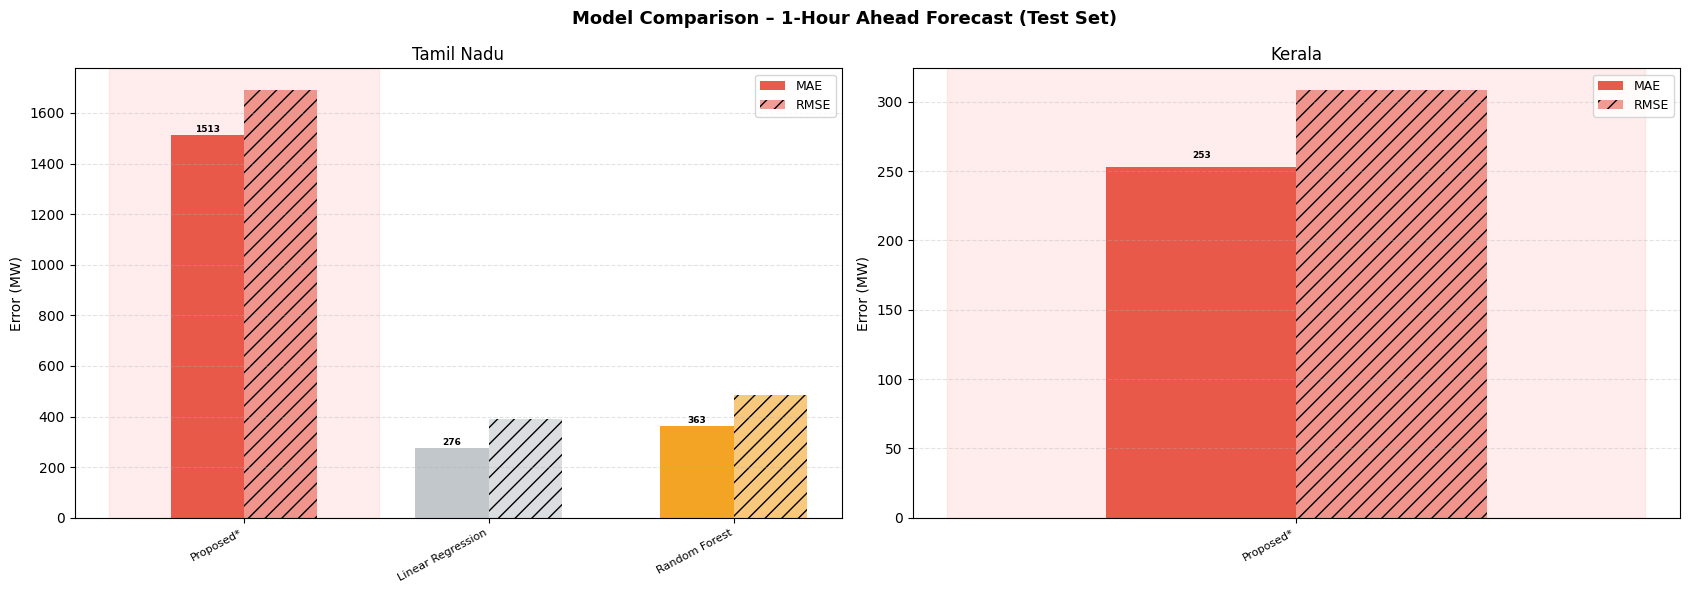

✅ Plot A: Model Comparison saved


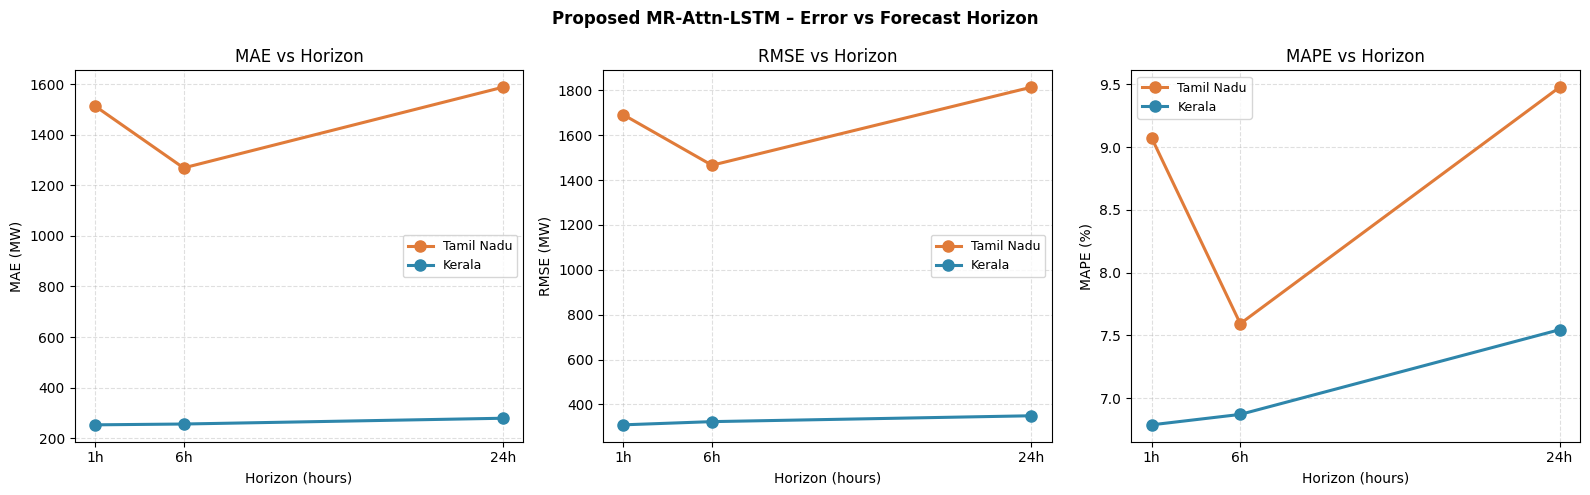

✅ Plot B: Multi-Horizon Error saved


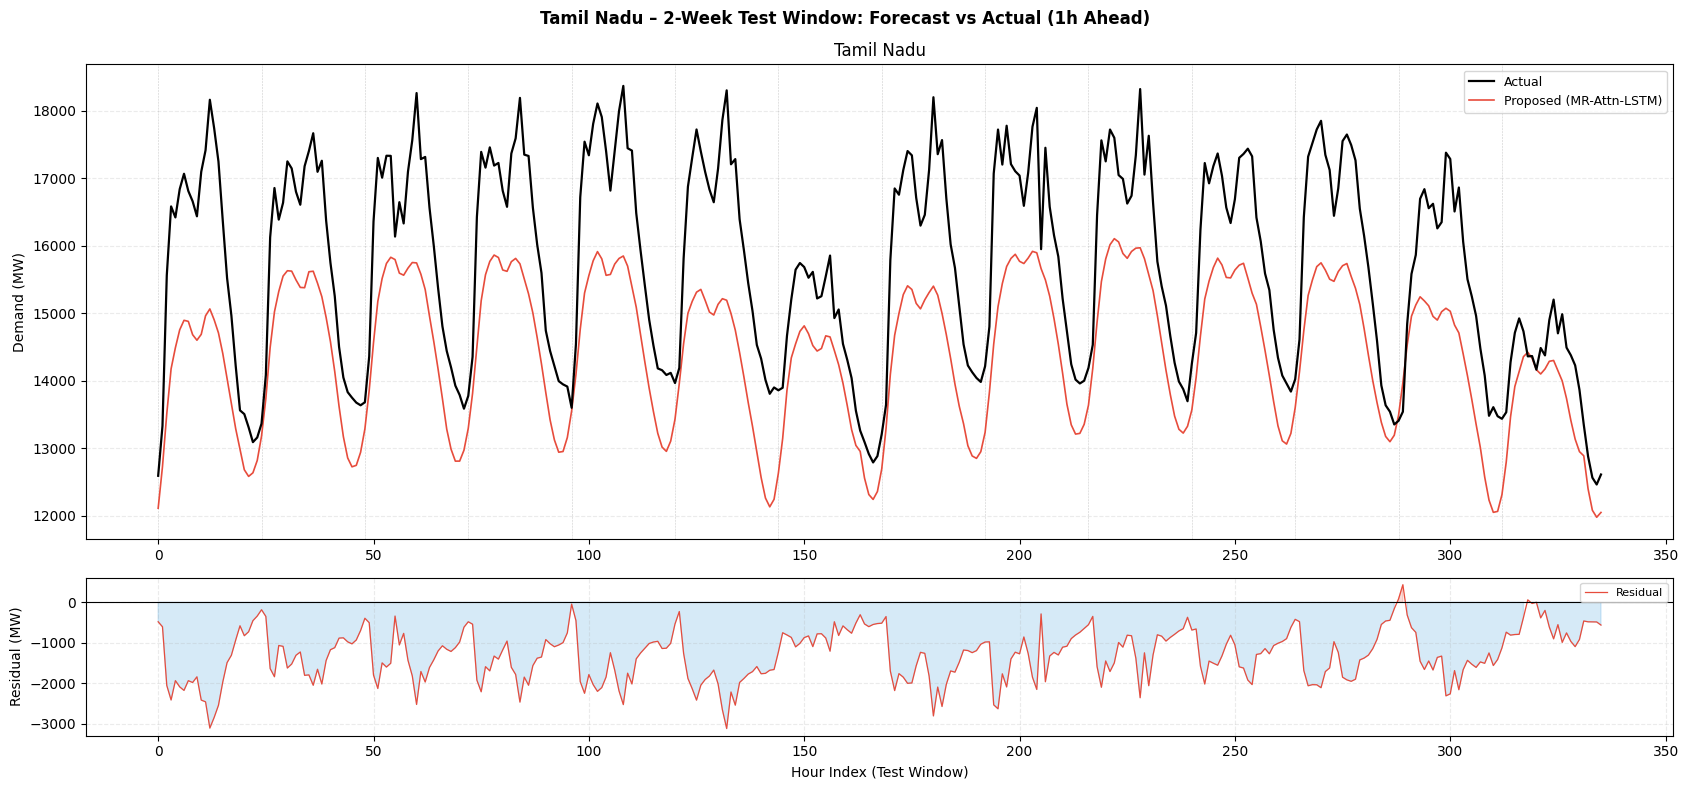

✅ Plot C: Forecast vs Actual – Tamil Nadu saved


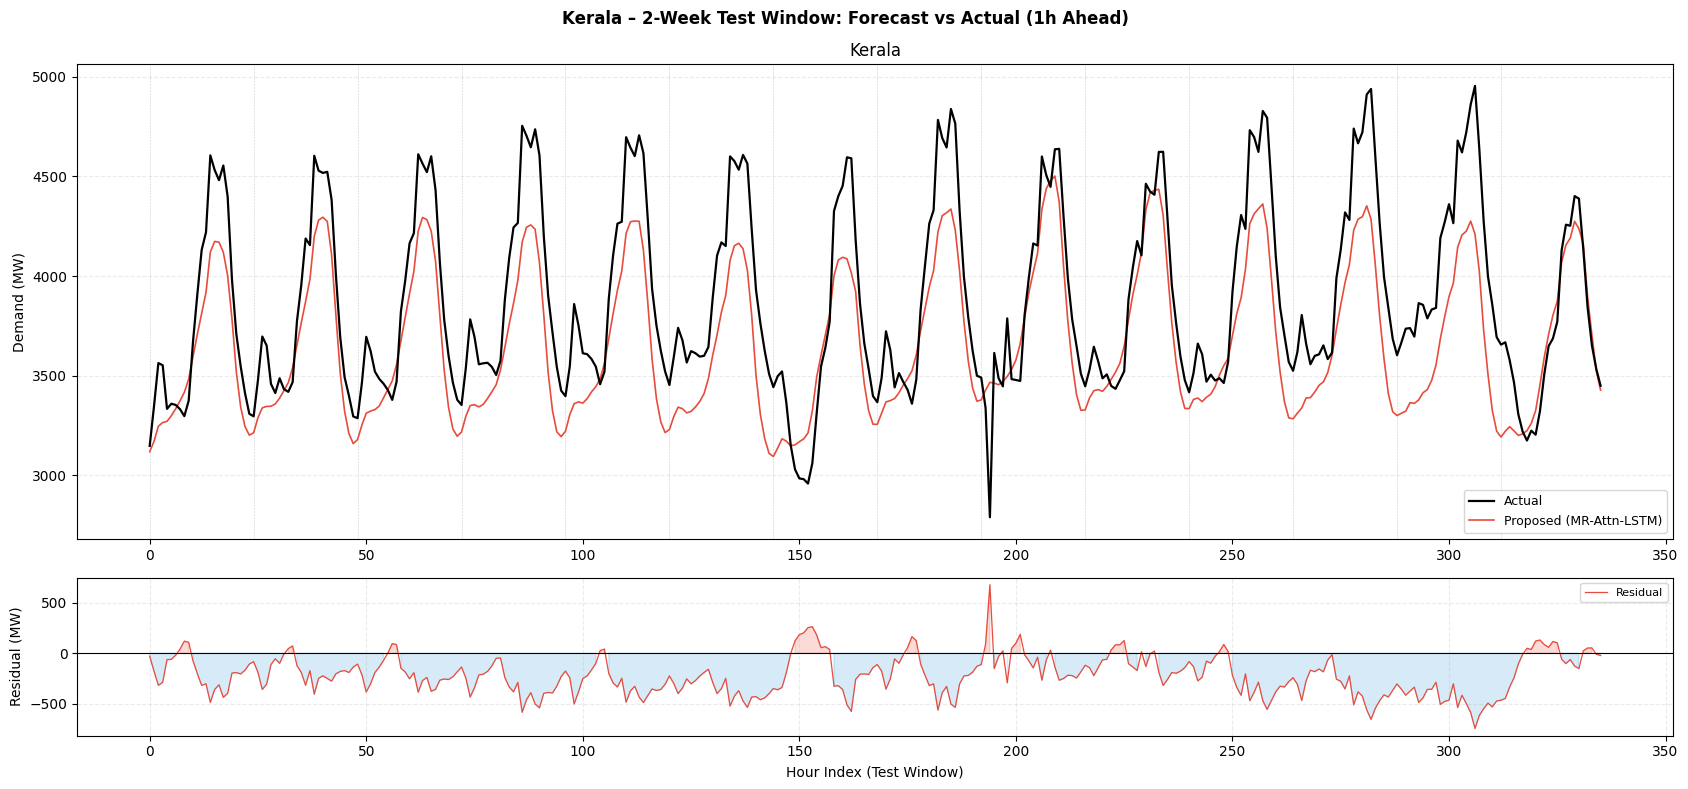

✅ Plot C: Forecast vs Actual – Kerala saved


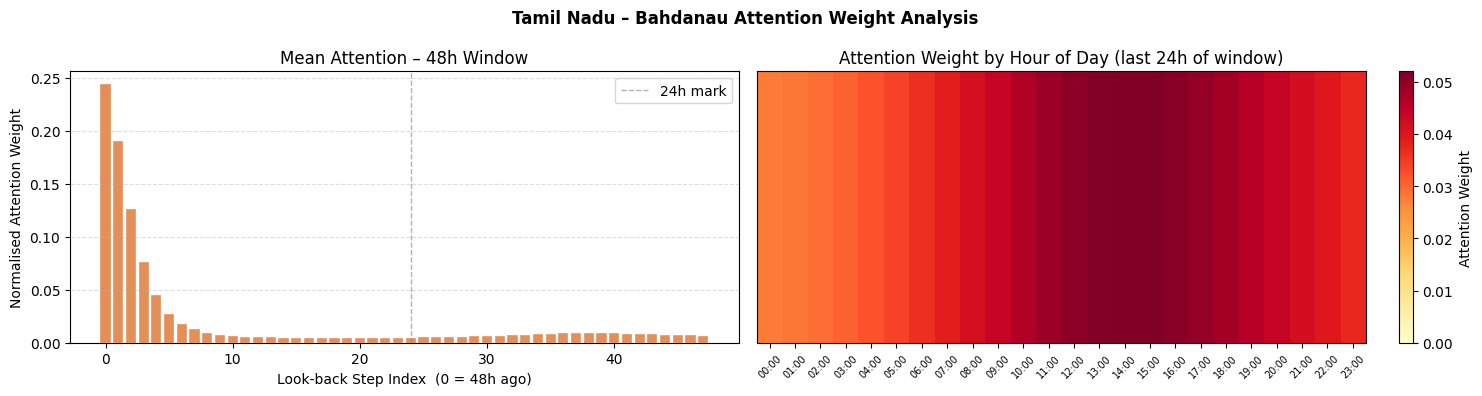

✅ Plot D: Attention Heatmap – Tamil Nadu saved


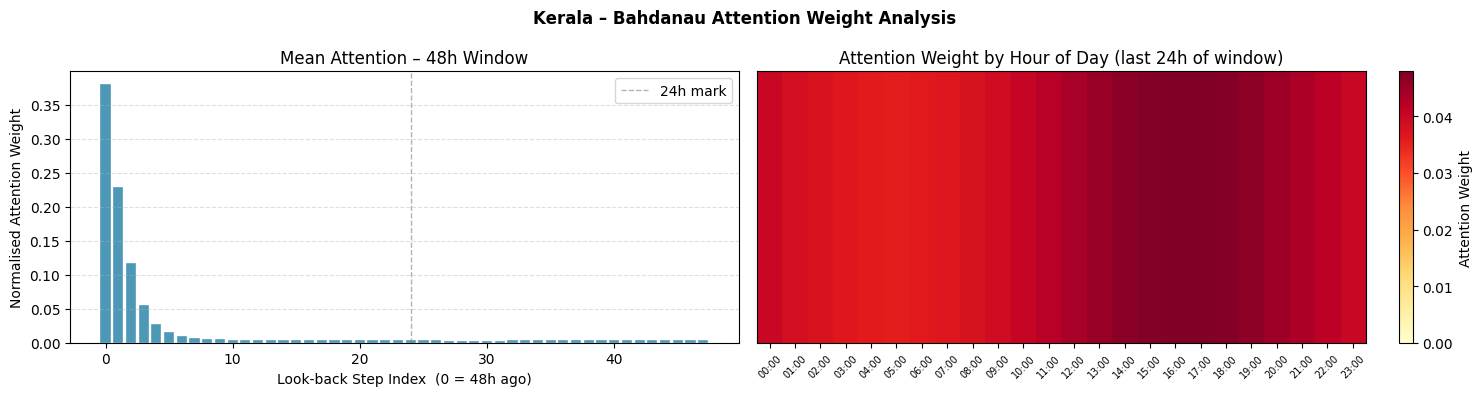

✅ Plot D: Attention Heatmap – Kerala saved


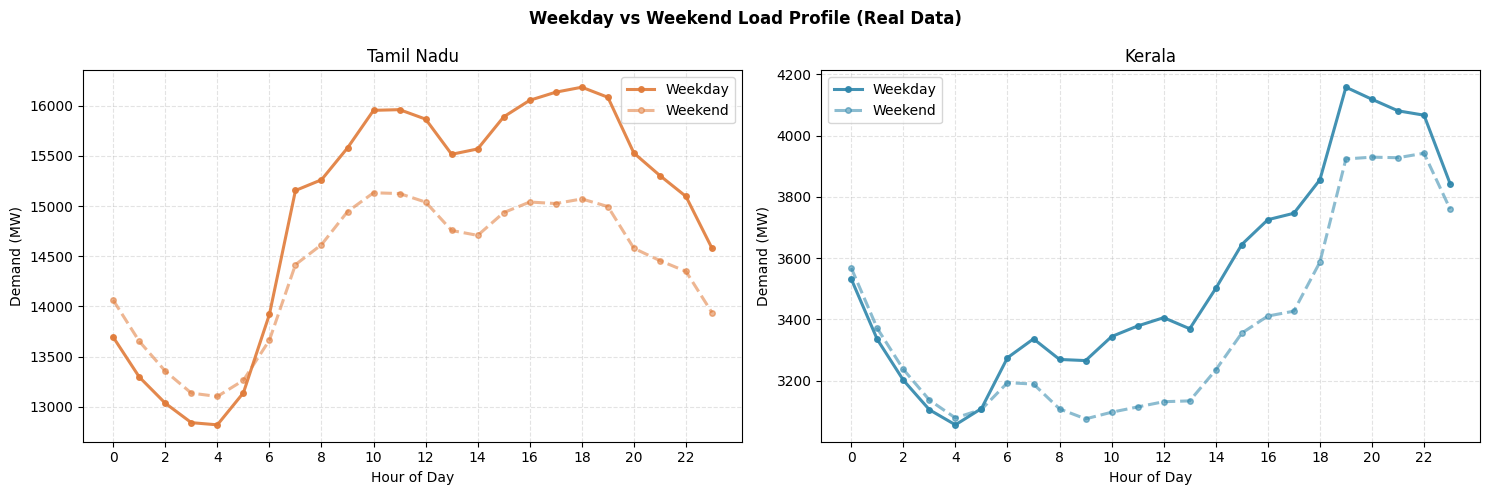

✅ Plot E: Weekday vs Weekend saved


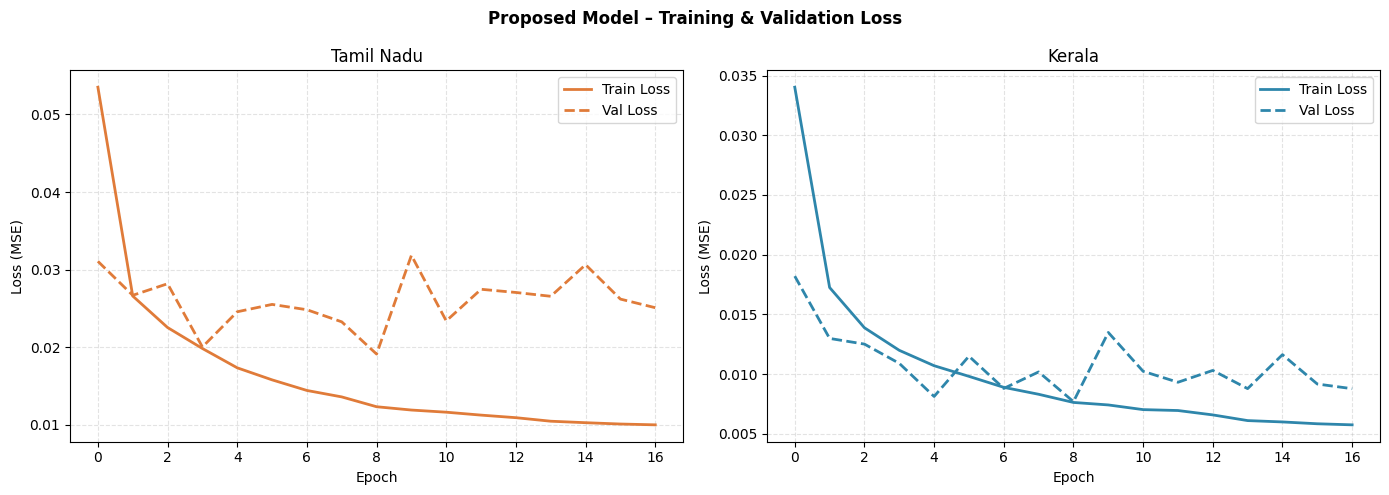

✅ Plot F: Training Loss saved

✅ All 6 paper-quality plots saved to /content/outputs/plots/


In [ ]:
# ─── CELL 10: Paper-Quality Plots ────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import numpy as np, os

os.makedirs("/content/outputs/plots", exist_ok=True)

COLORS = {"Tamil Nadu": "#E07B39", "Kerala": "#2E86AB"}
HORIZONS = [1, 6, 24]

MODEL_COLORS = {
    "Linear Regression"       : "#BDC3C7",
    "Random Forest"           : "#F39C12",
    "Gradient Boosting"       : "#E67E22",
    "LSTM (Baseline)"         : "#3498DB",
    "GRU (Baseline)"          : "#9B59B6",
    "CNN-LSTM"                : "#1ABC9C",
    "Proposed (MR-Attn-LSTM)" : "#E74C3C",
}

# ── PLOT A: Model Comparison Bar Chart ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Model Comparison – 1-Hour Ahead Forecast (Test Set)",
             fontsize=13, fontweight="bold")

for ax_i, (state, sr) in enumerate(ALL_RESULTS.items()):
    ax = axes[ax_i]
    names, maes, rmses = [], [], []
    for model, hs in sr.items():
        h = "1" if "1" in hs else list(hs.keys())[0]
        if not isinstance(hs[h], dict) or "MAE" not in hs[h]:
            continue
        names.append(model)
        maes.append(hs[h]["MAE"])
        rmses.append(hs[h]["RMSE"])

    x = np.arange(len(names)); w = 0.3
    c = [MODEL_COLORS.get(n, "#888") for n in names]
    b1 = ax.bar(x-w/2, maes,  width=w, color=c, alpha=0.92, label="MAE")
    b2 = ax.bar(x+w/2, rmses, width=w, color=c, alpha=0.55, label="RMSE", hatch="//")
    for b, v in zip(b1, maes):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
                f"{v:.0f}", ha="center", va="bottom", fontsize=6.5, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(
        [n.replace(" (Baseline)","").replace(" (MR-Attn-LSTM)","*")
         for n in names], rotation=28, ha="right", fontsize=8)
    ax.set_ylabel("Error (MW)"); ax.set_title(state)
    ax.legend(fontsize=9); ax.grid(axis="y", linestyle="--", alpha=0.35)
    for i, nm in enumerate(names):
        if "Proposed" in nm:
            ax.axvspan(i-0.55, i+0.55, alpha=0.07, color="red", zorder=0)

plt.tight_layout()
plt.savefig("/content/outputs/plots/02_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot A: Model Comparison saved")


# ── PLOT B: Multi-Horizon Error Degradation ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Proposed MR-Attn-LSTM – Error vs Forecast Horizon",
             fontsize=12, fontweight="bold")

for m_i, (metric, unit) in enumerate([("MAE","MW"), ("RMSE","MW"), ("MAPE","%")]):
    ax = axes[m_i]
    for state, sr in ALL_RESULTS.items():
        if "Proposed (MR-Attn-LSTM)" not in sr:
            continue
        hd = sr["Proposed (MR-Attn-LSTM)"]
        hs = sorted([int(k) for k in hd.keys()])
        vals = [hd[str(h)][metric] for h in hs]
        ax.plot(hs, vals, marker="o", lw=2.2, ms=8,
                color=COLORS[state], label=state)
    ax.set_xlabel("Horizon (hours)"); ax.set_ylabel(f"{metric} ({unit})")
    ax.set_title(f"{metric} vs Horizon")
    ax.set_xticks(HORIZONS)
    ax.set_xticklabels([f"{h}h" for h in HORIZONS])
    ax.legend(fontsize=9); ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("/content/outputs/plots/03_multi_horizon.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot B: Multi-Horizon Error saved")


# ── PLOT C: Forecast vs Actual (2-week sample) ────────────────────
for state in ["Tamil Nadu", "Kerala"]:
    split_data = splits[state]
    pred_store = split_data[8]          # (actual_mw, pred_mw) per horizon
    actual_1h, pred_1h = pred_store[1]
    n_s  = min(336, len(actual_1h))     # up to 2 weeks
    act  = actual_1h[:n_s]
    pred = pred_1h[:n_s]
    idx  = np.arange(n_s)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(17, 8),
                                    gridspec_kw={"height_ratios": [3, 1]})
    fig.suptitle(f"{state} – 2-Week Test Window: Forecast vs Actual (1h Ahead)",
                 fontsize=12, fontweight="bold")

    ax1.plot(idx, act,  color="black",   lw=1.6, label="Actual",   zorder=6)
    ax1.plot(idx, pred, color="#E74C3C", lw=1.2, label="Proposed (MR-Attn-LSTM)", zorder=5)
    for d in range(0, n_s, 24):
        ax1.axvline(d, color="gray", lw=0.4, ls="--", alpha=0.4)
    ax1.set_ylabel("Demand (MW)"); ax1.set_title(state)
    ax1.legend(fontsize=9); ax1.grid(axis="y", linestyle="--", alpha=0.25)

    residual = pred - act
    ax2.plot(idx, residual, color="#E74C3C", lw=0.9, label="Residual")
    ax2.fill_between(idx, residual, 0, where=pred>act, alpha=0.2, color="#E74C3C")
    ax2.fill_between(idx, residual, 0, where=pred<act, alpha=0.2, color="#3498DB")
    ax2.axhline(0, color="black", lw=0.8)
    ax2.set_xlabel("Hour Index (Test Window)"); ax2.set_ylabel("Residual (MW)")
    ax2.legend(fontsize=8); ax2.grid(linestyle="--", alpha=0.25)

    plt.tight_layout()
    fname = f"/content/outputs/plots/04_forecast_actual_{state.replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Plot C: Forecast vs Actual – {state} saved")


# ── PLOT D: Attention Weight Heatmap ──────────────────────────────
for state in ["Tamil Nadu", "Kerala"]:
    aw = attn_weights_store[state]      # (N, T, 1)
    attn_mean = aw[:, :, 0].mean(axis=0)
    attn_mean /= attn_mean.sum()
    last24 = attn_mean[-24:] / attn_mean[-24:].sum()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
    fig.suptitle(f"{state} – Bahdanau Attention Weight Analysis",
                 fontsize=12, fontweight="bold")

    ax1.bar(range(len(attn_mean)), attn_mean,
            color=COLORS[state], alpha=0.85, edgecolor="white", lw=0.3)
    ax1.axvline(24, color="gray", lw=1, ls="--", alpha=0.6, label="24h mark")
    ax1.set_xlabel("Look-back Step Index  (0 = 48h ago)")
    ax1.set_ylabel("Normalised Attention Weight")
    ax1.set_title("Mean Attention – 48h Window")
    ax1.legend(); ax1.grid(axis="y", linestyle="--", alpha=0.4)

    im = ax2.imshow(last24.reshape(1, 24), aspect="auto",
                    cmap="YlOrRd", vmin=0)
    ax2.set_xticks(range(24))
    ax2.set_xticklabels([f"{h:02d}:00" for h in range(24)],
                        rotation=45, fontsize=7)
    ax2.set_yticks([])
    ax2.set_title("Attention Weight by Hour of Day (last 24h of window)")
    plt.colorbar(im, ax=ax2, fraction=0.04, label="Attention Weight")

    plt.tight_layout()
    fname = f"/content/outputs/plots/05_attention_{state.replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Plot D: Attention Heatmap – {state} saved")


# ── PLOT E: Weekday vs Weekend Profile ────────────────────────────
# Rebuild df from raw if needed
try:
    _ = df
except NameError:
    import pandas as pd, glob
    xlsx_files = glob.glob("/content/*.xlsx")
    FILENAME   = xlsx_files[0]
    df_raw = pd.read_excel(FILENAME)
    def parse_dh(row):
        dp, tp = row["Date_Hour"].rsplit(" ", 1)
        return pd.to_datetime(f"{dp}-{row['Year']} {tp}", format="%d-%b-%Y %I%p")
    df_raw["Datetime"] = df_raw.apply(parse_dh, axis=1)
    df = df_raw.copy()
    df["HourOfDay"] = df["Datetime"].dt.hour
    df["DayOfWeek"] = df["Datetime"].dt.dayofweek
    df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

df["HourOfDay"] = df["Datetime"].dt.hour
df["IsWeekend"] = (df["Datetime"].dt.dayofweek >= 5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Weekday vs Weekend Load Profile (Real Data)",
             fontsize=12, fontweight="bold")
for i, state in enumerate(["Tamil Nadu", "Kerala"]):
    ax  = axes[i]
    sub = df[df["State"] == state]
    for is_we, label, ls in [(0,"Weekday","-"), (1,"Weekend","--")]:
        grp = sub[sub["IsWeekend"]==is_we].groupby("HourOfDay")["Demand_MW"].mean()
        ax.plot(grp.index, grp.values, lw=2.2, ls=ls, marker="o", ms=4,
                color=COLORS[state],
                alpha=0.9 if is_we==0 else 0.55, label=label)
    ax.set_title(state); ax.set_xlabel("Hour of Day"); ax.set_ylabel("Demand (MW)")
    ax.set_xticks(range(0, 24, 2)); ax.legend(); ax.grid(ls="--", alpha=0.35)

plt.tight_layout()
plt.savefig("/content/outputs/plots/06_weekday_weekend.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot E: Weekday vs Weekend saved")


# ── PLOT F: Training Loss Curve ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Proposed Model – Training & Validation Loss",
             fontsize=12, fontweight="bold")
for i, state in enumerate(["Tamil Nadu", "Kerala"]):
    ax = axes[i]
    h  = train_histories[state]
    ax.plot(h.history["loss"],     lw=2, label="Train Loss", color=COLORS[state])
    ax.plot(h.history["val_loss"], lw=2, label="Val Loss",
            color=COLORS[state], ls="--")
    ax.set_title(state); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (MSE)")
    ax.legend(); ax.grid(ls="--", alpha=0.35)

plt.tight_layout()
plt.savefig("/content/outputs/plots/07_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot F: Training Loss saved")

print("\n✅ All 6 paper-quality plots saved to /content/outputs/plots/")

In [ ]:
# ─── CELL 11: Download All Outputs as ZIP ────────────────────────
import shutil
from google.colab import files

# Zip everything
shutil.make_archive("/content/load_forecast_outputs", "zip", "/content/outputs")
print("📦 Archive created: load_forecast_outputs.zip")

# Download
files.download("/content/load_forecast_outputs.zip")
print("✅ Download started!")
print("\nContents:")
import subprocess
result = subprocess.run(["unzip","-l","/content/load_forecast_outputs.zip"],
                        capture_output=True, text=True)
print(result.stdout)

📦 Archive created: load_forecast_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!

Contents:
Archive:  /content/load_forecast_outputs.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2026-03-10 03:29   plots/
        0  2026-03-10 03:26   results/
  1642382  2026-03-10 02:58   mr_attn_lstm_Tamil_Nadu.keras
  1642382  2026-03-10 03:00   mr_attn_lstm_Kerala.keras
   128292  2026-03-10 03:29   plots/07_training_loss.png
    95983  2026-03-10 03:29   plots/05_attention_Kerala.png
   396100  2026-03-10 03:29   plots/04_forecast_actual_Tamil_Nadu.png
    99699  2026-03-10 03:29   plots/02_model_comparison.png
   363897  2026-03-10 03:29   plots/04_forecast_actual_Kerala.png
   180039  2026-03-10 03:29   plots/06_weekday_weekend.png
   131975  2026-03-10 03:29   plots/03_multi_horizon.png
    92525  2026-03-10 03:29   plots/05_attention_Tamil_Nadu.png
      383  2026-03-10 03:26   results/Table2_MultiHorizon.csv
      485  2026-03-10 03:26   results/Table_AllResults.csv
      619  2026-03-10 03:26   results/Table1_lat